# BE - Processus de Poisson et application en actuariat

## Projet : Cramér-Lundberg et modélisation du risque au sein d'une assurance non vie
**Auteurs:** Mehdi ELLOUMI - Skander RAHAL <br>
**Date:** 21/05/2024


## Introduction:
L'objectif principal du projet est d'étudier la modélisation des risques au sein d'une assurance non-vie (à l'instard de l'assurance habitation ou bien l'assurance automobile).
<br>
Dans le cadre de notre étude , on va principalement se focaliser sur le modèle de Cramér-Lundberg.
<br>
<br>
En assurance non-vie, les sinistres sont des événements indésirables et imprévus, indépendants de l'assuré, souvent résultant en des dommages matériels, avec une fréquence variable et pouvant entraîner des coûts variés.
<br>
<br>
La nature incertaine de la survenue des sinistres et de leurs coûts introduit un caractère aléatoire : il semble donc approprié de les modéliser avec des variables aléatoires. 
<br> 
Ainsi, nous pouvons étudier le risque associé à ce phénomène random, ce qui implique de le quantifier et de le gérer. 
<br>
Par conséquent, nous modéliserons le capital de l'assureur comme une quantité aléatoire dépendante du temps et examinerons le risque de faillite.

## Construction du modèle:

On note R(t) la réserve d'une assurance à un instant t.<br>
On suppose que u représente l'apport initial des assurés. <br>
On a donc qu'à t=0 :
$$R(0)=u$$ 

On considère ensuite un scénario sans aucun sinistre. L'assuré paie une prime à l'assurance de valeur p à chaque unité de temps.
Dans ce cas , la réserve de l'assurance décrit donc une droite affine en fonction du temps définie comme ci-dessous :
$$ R(t)=u+p*t$$

Maintenant , on introduit les sinistres pour pouvoir définir le modèle de Cramér-Lundberg. On note S(t) le coût total des sinistres survenus avant un instant t qui représente une variable aléatoire (comme mentionné dans l'introduction) alors la réserve s'écrit donc :
$$ R(t) =u+p*t-S(t)$$

On va à présent préciser l'expression de $S(t)$.<br>
Soit $X_i$ une variable aléatoire positive modélisant le coût du ième sinistre.On suppose que les sinistres sont de même nature et indépendants , i.e les $(X_n)_{n \in \mathbb{N}^*}$ sont des variables aléatoires i.i.d et positives .<br>
On considère aussi une variable aléatoire $N_t$ qui compte le nombre des sinistes avant t où on a: 
$$S(t)=\sum_{i=1}^{N_t} X_i$$
On suppose que $(N_t)_{t \in \mathbb{R}^+}$ est un processus de poisson homogène d'intensité $\lambda>0$ et indépendant de $(Y_n)_{n \in \mathbb{N}^*}$.
De plus , d'après le cours le processus de comptage $(N_t)_{t \in \mathbb{R}^+}$ est défini par :<br>
$$N_t = \sum_{n=1}^\infty 1_{(T_n \leq t)}$$

## Etude du risque :

Afin de pouvoir évaluer le risque , on associe à notre modèle la notion de probabilité de ruine qui est donnée par : <br>
$$\Phi(u) = P(\exists t \geq 0 : R(t) < 0)$$ <br>
Afin de mieux quantifier cette probabilité , nous pouvons étudier l'évolution de $R(t)$ et la façon dont ses paramètres peuvent l'affecter.

### Espérance de $R_t$ et coefficient de chargement de sécurité:

Dans cette partie , on va calculer l'espérance de R(t) afin de pouvoir définir le coefficient de chargement de sécurité dont on l'exprimera en fonction de p et $\lambda$.

Nous calculons l'espérance de $R_t$ qui est définie comme :

$$
\mathbb{E}(R_t) = \mathbb{E}(u + p \times t - S_t)
$$

En simplifiant, cela devient :

$$
= u + p \times t - \mathbb{E}(S_t)
$$

En utilisant la formule de probabilité totale, nous avons :

$$
\mathbb{E}(S_t) = \sum_{n \geq 0} \mathbb{E}(S_t | N_t = n) \cdot \mathbb{P}(N_t = n)
$$

et pour une variable $S_t$ conditionnée par $N_t = n$,

$$
\mathbb{E}(S_t | N_t = n) = \mathbb{E}\left(\sum_{i=1}^n X_i \right) = n \mathbb{E}(X)
$$

car les $X_i$ sont indépendants et identiquement distribués et que $(N_t)_{t \in \mathbb{R}^+}$ est indépendant de $(X_n)_{n \in \mathbb{N}^*}$. 

Donc,

$$
\mathbb{E}(S_t) = \sum_{n \geq 0} n \cdot \mathbb{P}(N_t = n) \times \mathbb{E}(X)=\mathbb{E}(X)\times \sum_{n \geq 0} n \cdot \mathbb{P}(N_t = n)= \mathbb{E}(X) \mathbb{E}(N_t)
$$

Puisque $N_t$ est un processus de Poisson homogène avec une intensité $\lambda$, alors $\mathbb{E}(N_t) = \lambda t$. Ainsi, nous avons :

$$
\mathbb{E}(R_t) = u + p \times t - \lambda t \mathbb{E}(X) = u + t(p - \lambda \mathbb{E}(X))
$$


On définit ci-dessous différentes notions qu'on venait de présenter et qui seront utilisées par la suite pour effectuer nos simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

In [2]:
def N(x,T):
    i=0
    N=0
    while x>T[i]:
        N=N+1
        i=i+1
    return N

def S(x,T,Sm):
    if N(x,T)==0:
        return 0
    else:
        return Sm[N(x,T)-1]

def R(x,T,Sm):
    return u+p*x -S(x,T,Sm)

def E(x):
    return u+p*x - (lambda_poisson/e)*x

Maintenant , on introduit $\eta$ qui représente le coefficient de changement de sévérité. Son expression est donnée par :
$$\eta = \frac{p}{\lambda \times \mathbb{E}(X)} - 1$$

La monotonie de $\mathbb{E}(R_t)$ dépend du signe de $\eta$. En effet, on a :
$$\frac{d\mathbb{E}(R_t)}{dt} = p - \lambda \mathbb{E}(X)$$


On distingue 2 cas :

- **1er Cas** : $\frac{d\mathbb{E}(R_t)}{dt} > 0$ si $p - \lambda \mathbb{E}(X) > 0$ ce qui implique $\frac{p}{\lambda \times \mathbb{E}(X)} - 1 > 0$ et donc $\eta > 0$.

- **2ème Cas** : $\frac{d\mathbb{E}(R_t)}{dt} < 0$ si $p - \lambda \mathbb{E}(X) < 0$ ce qui implique $\frac{p}{\lambda \times \mathbb{E}(X)} - 1 < 0$ et donc $\eta <0$.


**Théorème : Les conditions de la ruine:** <br>
**a)**  Si $p - \lambda \mathbb{E}(X)>0$ alors il existe $u_0$ telque $\forall u \ge u_0$ on a $\phi(u) \le 1$  <br>
**b)**  Si $p - \lambda \mathbb{E}(X) < 0$ alors $\phi(u)=1  \forall u$ 

 **Démonstration du théorème :**

Nous commençons par montrer que $\forall u$:

$$
\frac{R(t)}{t} \overset{p.s.}{\longrightarrow} p - \lambda E(X) \text{ quand } t \to \infty
$$

D'après la loi des grands nombres, on sait que:

$$
\frac{N_t}{t} \overset{p.s.}{\longrightarrow} \lambda \text{ quand } t \to \infty
$$

On déduit que $ N_t \overset{p.s.}{\longrightarrow} \infty \text{ quand } t \to \infty$ et donc on a:

$$
\lim_{t \to \infty} N_t = \infty \implies \lim_{t \to \infty} \frac{1}{N_t} \sum_{i=1}^{N_t} X_i = E(X) \text{ p.s.}
$$

Donc,
$$
P\left(\lim_{t \to \infty} N_t = \infty\right) \leq P\left(\lim_{t \to \infty} \frac{1}{t} \sum_{i=1}^{N_t} X_i = E(X)\right) \leq 1
$$

or
$$
P\left(\lim_{t \to \infty} N_t = \infty\right) = 1
$$

$$
\text{d'où } P\left(\lim_{t \to \infty} \frac{1}{t} \sum_{i=1}^{N_t} X_i = E(X)\right) = 1
$$

Donc,

$$
\lim_{t \to \infty} \frac{1}{t} \sum_{i=1}^{N_t} X_i = \frac{N_t}{t} \frac{1}{N_t} \sum_{i=1}^{N_t} X_i \overset{p.s.}{\longrightarrow} \lambda E(X) \text{ quand } t \to \infty
$$

Et,

$$
\frac{R(t)}{t} = \frac{u + p t - \sum_{i=1}^{N_t} X_i}{t} \overset{p.s.}{\longrightarrow} p - \lambda E(X) \text{ quand } t \to \infty$$

Revenons aux deux cas **a)** et **b)** : <br>
**Cas a)**: Si $p - \lambda E(X) > 0$

$$
\frac{R(t)}{t} \overset{p.s.}{\longrightarrow} p - \lambda E(X) > 0 \text{ quand } t \to \infty
$$
Donc $R(t)\overset{p.s.}{\longrightarrow} \infty \text{ quand } t \to \infty $

On définit $M$ comme:

$$
M = \sup_{t \geq 0} (u - R(t)) = \sup_{t \geq 0} \left(-p t + \sum_{i=1}^{N_t} X_i\right)
$$

$M$ ne dépend donc pas de $u = R(0)$ et on sait que:

$$
u - R(t) \to -\infty \text{ quand } t \to \infty
$$

Donc, $M < +\infty$ presque sûrement. <br>
Donc , il existe $u_0 \geq 0$ tq :

$$
P(M> u_0) < 1
$$

Et si $R(0) = u > u_0$ alors,
On a que:

$$
P(M > u) \leq P(M > u_0) < 1
$$

On a:
$$
M>u
\Leftrightarrow
\sup_{t \geq 0} (u-R(t)) > u
$$

$$
\Leftrightarrow \sup_{t \geq 0} -R(t) > 0
$$
$$
\Leftrightarrow \inf_{t \geq 0} R(t) < 0
$$
$$
\Leftrightarrow \exists t_0 \geq 0 , R(t_0) < 0
$$
Donc:

$$
\Phi(u) = P(\exists t_0 \geq 0, R(t_0) < 0) = P(M > u) < 1$$

**Cas b)**: Si $p - \lambda E(X) < 0$
$$
\frac{R(t)}{t} \overset{p.s.}{\longrightarrow} p - \lambda E(X) < 0 \text{ as } t \to \infty
$$

Donc,

$$
\inf_{t \geq 0} \frac{R(t)}{t} < 0
$$

Ce qui veut dire que,

$$
\inf_{t \geq 0} R(t) < 0
$$

On a donc montré que :

$$
P\left(\inf_{t \geq 0} R(t) < 0\right) = P(\exists t_0 > 0, \text{ tel que } R(t_0) < 0) = \phi(u) = 1$$

## Simulations:

Maintenant , on va effectuer des simulation de $R_t$, suivant les 2 cas qu'on vient de présenter ci-dessus.<br>
On va donc introduire la notion de temps d'attente en fonction du temps d'arrivée.

$$
W_i = 
\begin{cases} 
T_1 & \text{si } i = 1 \\
T_i - T_{i-1} & \text{si } i \geq 2 
\end{cases}
$$


Donc le temps d'arrivée s'écrit : 
$$
T_n = \sum_{i=1}^n W_i
$$
où les $(W_i)$ sont i.i.d de loi $\text{Exp} (\lambda)$


Tous les outils mathématiques une fois à notre disposition , on peut commencer nos simulations :

# Premier cas: $p - \lambda E(X) > 0$

### a) Simulation et affichage

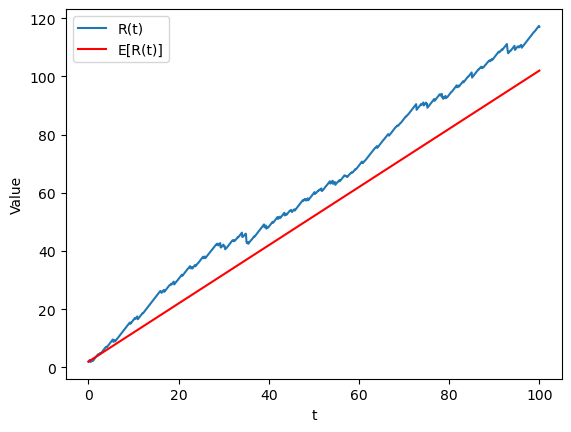

In [3]:
lambda_poisson=2
u=2
p=2
n=500
W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson (loi exponentielle de paramètre lambda)
T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
e=2 #paramètre de la loi associée aux Xi
X=np.random.exponential(1/e,n) #On a choisi que nos Xi suivent une loi exponentielle de paramètre e
Sm=np.cumsum(X)
x_total=100
x_lin=np.linspace(0,x_total,1000)
R_values=[R(x,T,Sm) for x in x_lin]
R_values=np.array(R_values)
E_values=[E(x) for x in x_lin]
E_values=np.array(E_values)
plt.plot(x_lin,R_values,label='R(t)')
plt.plot(x_lin,E_values,color='red',label='E[R(t)]')
plt.xlabel('t')
plt.ylabel('Value')
plt.legend()
plt.show()

### b) Estimation de la proba de ruine (Méthode de Monte Carlo):

In [4]:
N1=1000
count_negative =0
for _ in range(N1):
    W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson
    T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
    X=np.random.exponential(1/e,n)
    Sm=np.cumsum(X)
    R_values=[R(x,T,Sm) for x in x_lin]
    R_values=np.array(R_values)
    if np.any(R_values < 0):
            count_negative += 1
prob=count_negative / N1
print("Estimation de la probabilité de ruine :", prob)

Estimation de la probabilité de ruine : 0.067


Dans le cas où on a des valeurs de $p=2$ , $\lambda=2$ et $\mathbb{E}(X)=\frac{1}{e}=\frac{1}{2}$ ,on a que la probabilité de ruine est inférieure à 1. <br>
Ce qui vérifie bien le premier résultat de notre théorème.

# Deuxième Cas: $p - \lambda E(X) < 0$

### a) Simulation et Affichage

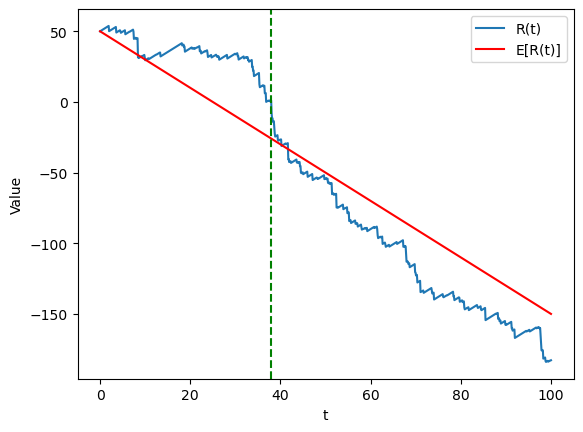

In [5]:
lambda_poisson=2
u=50
p=2
n=500
W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson
T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
e=1/2
X=np.random.exponential(1/e,n)
Sm=np.cumsum(X)
R_values=[R(x,T,Sm) for x in x_lin]
R_values=np.array(R_values)
E_values=[E(x) for x in x_lin]
E_values=np.array(E_values)
plt.plot(x_lin,R_values,label='R(t)')
plt.plot(x_lin,E_values,color='red',label='E[R(t)]')
plt.xlabel('t')
plt.ylabel('Value')
plt.legend()

zero_crossings = np.where(np.diff(np.sign(R_values)))[0]

# S'assurer qu'il y a au moins un point où R passe par zéro
if len(zero_crossings) > 0:
    # Prendre le premier point où R passe par zéro
    x_zero = x_lin[zero_crossings[0]]
    
    # Tracer une ligne en pointillés verticalement à travers ce point
    plt.axvline(x_zero, linestyle='--', color='green', label='R passe par 0')
    
plt.show()

### b) Estimation de la proba de ruine (Méthode de Monte Carlo) :

In [6]:
N1=1000
count_negative =0
for _ in range(N1):
    W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson
    T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
    X=np.random.exponential(1/e,n)
    Sm=np.cumsum(X)
    R_values=[R(x,T,Sm) for x in x_lin]
    R_values=np.array(R_values)
    if np.any(R_values < 0):
            count_negative += 1
prob=count_negative / N1
print("Estimation de la probabilité de ruine :", prob)
    

Estimation de la probabilité de ruine : 1.0


Dans le cas où on a des valeurs de $p=2$ , $\lambda=2$ et $\mathbb{E}(X)=\frac{1}{e}=2$ ,on a que la probabilité de ruine est égale à 1. <br>
Ce qui vérifie bien le deuxième résultat de notre théorème.

## La borne supérieure de la probabilité de ruine:

On sait que l'assureur doit choisir $ p - \lambda E(X) > 0 $ pour assumer les conditions de profit.

 Dans ce cas, la probabilité de ruine est strictement inférieure à 1 mais il nous manque d'autres informations (Est-ce qu'elle est proche de 0 ou de 1).

### Théorème de la borne supérieure :

Soit  $R(t) = u + pt - \sum_{i=1}^{N_t} X_i $ un modèle Cramér-Lundberg et $\phi(u) $ la probabilité de ruine avec $ E[N_1] = \lambda > 0 $.

Si $ p - \lambda E(X_1) \geq 0 $ et $\frac{\lambda E[e^{X_1}]}{\lambda +p}\leq 1$, alors il existe $ C \geq 0 $ tel que:

$$
\phi(u) < C e^{- u}
$$


In [7]:
lambda_poisson=2
u=0
p=2
n=500
e=2

### Verification du théorème de la borne supérieure ( On se met dans les bonnes conditions du théorème):

In [8]:
N1=1000
count_negative =0
for _ in range(N1):
    W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson
    T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
    X=np.random.exponential(1/e,n)
    Sm=np.cumsum(X)
    R_values=[R(x,T,Sm) for x in x_lin]
    R_values=np.array(R_values)
    if np.any(R_values < 0):
            count_negative += 1
prob=count_negative / N1
print("Estimation de la probabilité de ruine:", prob)
    

Estimation de la probabilité de ruine: 0.437


Maintenant, on ajoute un facteur log(10) à notre capital initial u.

In [9]:
lambda_poisson=2
u=np.log(10)
p=2
n=500
e=2

In [10]:
N1=1000
count_negative =0
for _ in range(N1):
    W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson
    T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
    X=np.random.exponential(1/e,n)
    Sm=np.cumsum(X)
    R_values=[R(x,T,Sm) for x in x_lin]
    R_values=np.array(R_values)
    if np.any(R_values < 0):
            count_negative += 1
prob=count_negative / N1
print("Estimation de la probabilité de ruine :", prob)

Estimation de la probabilité de ruine : 0.049


##### On vérifie bien qu'en rajoutant 2.3=log(10) à la valeur de u on gagne une division par un facteur de 10 en probabilité de ruine

En effet , sous les bonnes conditions , on a que
$$
\phi(u+log(10)) < C e^{- (u+log(10))} 
$$
Donc
$$
\phi(u+log(10)) < C e^{-u} e^{-log(10)} 
$$
Donc
$$
\phi(u+log(10)) < \frac{C e^{-u}}{e^{log(10)}}
$$
Ainsi 
$$
\phi(u+log(10)) < \frac{C e^{-u}}{10}
$$


## Méthode de l'Importance Sampling

### Théorie de l'Importance Sampling avec l'Espérance
L'importance sampling est une méthode très utile pour estimer des espérances mathématiques sous des distributions difficiles à échantillonner directement. La méthode permet d'effectuer des estimations efficaces en ajustant l'échantillonnage à des zones de l'espace d'état plus pertinentes pour le calcul de l'espérance.

#### Estimation de l'Espérance
Soit $X$ une variable aléatoire avec une densité de probabilité $f$ (la distribution cible) et $g$ une fonction dont on souhaite estimer l'espérance $\mathbb{E}[g(X)]$. L'espérance est définie par:

$$
\mathbb{E}[g(X)] = \int g(x) f(x) \, dx
$$

En importance sampling, on choisit une autre densité $q$ (la distribution d'importance) pour effectuer l'échantillonnage. Les valeurs échantillonnées sont ensuite utilisées pour calculer une estimation de l'espérance via les poids dérivés du rapport des densités.

#### Calcul avec Importance Sampling
Les étapes suivantes décrivent le calcul de $\mathbb{E}[g(X)]$ via l'importance sampling:

1. **Échantillonnage :** Générer $n$ échantillons $x_1, x_2, \ldots, x_n$ de la distribution d'importance $q(x)$.
2. **Pondération :** Calculer les poids $w_i =\frac{f(x_i)}{q(x_i)}$ pour chaque échantillon $x_i$.
3. **Estimation pondérée :** L'estimateur de l'espérance est donné par:
   $
   \hat{\mathbb{E}}[g(X)] = \frac{1}{n} \sum_{i=1}^n w_i g(x_i)
   $
   ou, en normalisant les poids,
   $
   \hat{\mathbb{E}}[g(X)] = \frac{\sum_{i=1}^n w_i g(x_i)}{\sum_{i=1}^n w_i}
   $

#### Importance des Poids
Les poids $w_i$ ajustent l'influence de chaque échantillon $x_i$ pour correspondre à l'espérance sous la distribution cible. Sans ces poids, l'échantillonnage à partir de $q(x)$ne serait pas représentatif de $f(x)$, rendant l'estimation invalide.


### Application de la méthode de l'Importance Sampling sur la loi normale

 Pour appliquer l'importance sampling à l'estimation de la probabilité que $X > 5$ sous une loi normale standard $N(0,1)$, en utilisant une distribution d'importance, par exemple une loi normale $N(5,1)$, on suit ces étapes incluant le calcul des poids et l'espérance avec la fonction indicatrice :

#### Étapes de l'Importance Sampling
**Choix de la Distribution d'Importance :**
Nous choisissons une distribution normale centrée en 5 avec un écart-type de 1, pour augmenter la fréquence d'échantillons dans la zone où $X > 5$.

#### Fonctions de Densité :
- La densité cible $f(x)$ pour $N(0,1)$ est $f(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$.
- La densité d'importance $q(x)$ pour $N(5,1)$ est $q(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{(x-5)^2}{2}}$.

#### Génération d'Échantillons :
Générez $n$ échantillons $x_1, x_2, \ldots, x_n$ à partir de $q(x)$.

#### Calcul des Poids :
Chaque échantillon $x_i$ obtient un poids $w_i = \frac{f(x_i)}{q(x_i)}$, calculé comme :
$w_i = \frac{\frac{1}{\sqrt{2\pi}} e^{-x_i^2/2}}{\frac{1}{\sqrt{2\pi}} e^{-\frac{(x_i-5)^2}{2}}} = e^{-\frac{x_i^2}{2} + \frac{x_i^2 - 10x_i + 25}{2}} $


#### Calcul de l'Espérance avec Fonction Indicatrice :
L'espérance de $g(x) = \mathbf{1}_{x > 5}$ est calculée en utilisant les poids :
$ \hat{\mathbb{E}}[g(X)] = \frac{\sum_{i=1}^n w_i g(x_i)}{\sum_{i=1}^n w_i} $
où $g(x_i) = 1$ si $x_i > 5$ sinon $g(x_i) = 0$.


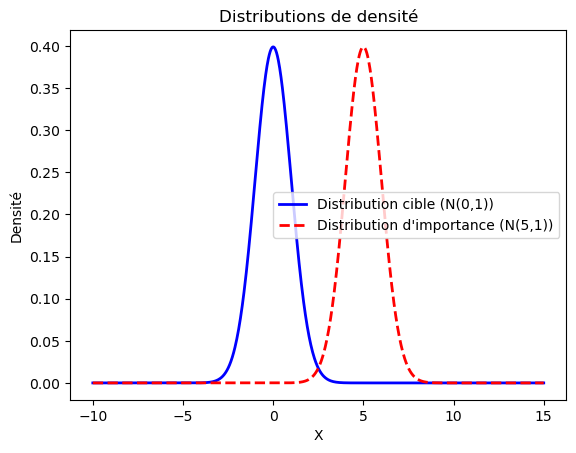

In [11]:
# Fonction de densité de la distribution cible pour X (loi normale centrée réduite)
def target_distribution_X(x):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * x**2)

# Fonction de densité de la distribution d'importance pour X (par exemple, une loi normale centrée en 5)
def importance_distribution_X(x):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * (x - 5)**2)

x_sample = np.linspace(-10, 15, 1000)
# Calculer les valeurs des densités
target_density = target_distribution_X(x_sample)
importance_density = importance_distribution_X(x_sample)

# Tracer la distribution cible
plt.plot(x_sample, target_density, label='Distribution cible (N(0,1))', color='blue', linewidth=2)
# Ajouter la distribution d'importance
plt.plot(x_sample, importance_density, label='Distribution d\'importance (N(5,1))', color='red', linestyle='dashed', linewidth=2)

# Ajouter les étiquettes et la légende
plt.xlabel('X')
plt.ylabel('Densité')
plt.title('Distributions de densité')
plt.legend()

# Afficher le graphique
plt.show()



In [12]:
N1 = 100000  # Nombre d'échantillons à générer

# Générer des échantillons à partir de la distribution d'importance pour X
X_samples = np.random.normal(loc=5, scale=1, size=N1)

# Calculer les poids d'importance pour X
weights_X = target_distribution_X(X_samples) / importance_distribution_X(X_samples)

# Calculer le nombre de réalisations où X > 5 pondérées par les poids d'importance
weighted_X_gt_5 = np.sum((X_samples > 5) * weights_X)  # Pondération par les poids d'importance

# Calculer la somme des poids d'importance pour normaliser
sum_weights_X = np.sum(weights_X)

# Calculer la probabilité que X > 5
prob_X_gt_5 = weighted_X_gt_5 / sum_weights_X

print("Estimation de la probabilité que X > 5 :", prob_X_gt_5)

# Calculer la probabilité que X > 5 pour une loi normale centrée réduite (valeur numérique)
prob_X_gt_5_exact = 1 - scipy.stats.norm.cdf(5)

print("Probabilité que X > 5 pour une loi normale centrée réduite (valeur numérique) :", prob_X_gt_5_exact)

Estimation de la probabilité que X > 5 : 9.178578053044834e-07
Probabilité que X > 5 pour une loi normale centrée réduite (valeur numérique) : 2.866515719235352e-07


### Application de la méthode de l'Importance Sampling pour le calcul de la probabilité de ruine:

Dans notre étude de la probabilité de ruine, nous avons employé la technique d'échantillonnage d'importance pour augmenter la précision des simulations de Monte Carlo, en particulier pour mieux capturer les événements de ruine qui sont intrinsèquement rares. Pour ce faire, nous avons modifié la distribution exponentielle des montants des sinistres, choisissant un paramètre $e'$ plus petit que le paramètre original $e$ .<br>
Cette approche a pour effet d'augmenter artificiellement la taille moyenne des sinistres simulés, passant ainsi d'une moyenne de $\frac{1}{e}$ à $\frac{1}{e'}$  et de rendre les événements de grande perte plus fréquents dans nos simulations.
<br>
Dans le contexte de l'échantillonnage d'importance où les sinistres sont générés selon une distribution exponentielle modifiée, le poids $w(x)$ pour un sinistre de taille $x$ généré avec le paramètre modifié $e'$ (par rapport au paramètre original $e$) est donné par :

$ w(x) = \frac{f_e(x)}{f_{e'}(x)} $

Où :

- $f_e(x) = e \cdot \exp(-e \cdot x)$ est la densité de probabilité de la distribution originale.
- $f_{e'}(x) = e' \cdot \exp(-e' \cdot x)$ est la densité de probabilité de la distribution biaisée.

En substituant ces valeurs dans la formule du poids, nous obtenons :

$ w(x) = \frac{e \cdot \exp(-e \cdot x)}{e' \cdot \exp(-e' \cdot x)} = \frac{e}{e'} \cdot \exp((e' - e) \cdot x) $

Cette formule permet d'ajuster les résultats des simulations pour que l'estimation finale de la probabilité de ruine reste fidèle à la distribution originale des risques, compensant ainsi le biais introduit par la modification de la distribution utilisée pour générer les données.
<br> Cette approche améliore significativement la fiabilité des estimations dans les régions critiques de la distribution des résultats, permettant ainsi une évaluation plus précise et plus informative des risques associés aux politiques d'assurance envisagées.

#### Visualisation du problème rencontré avec la méthode de Monte Carlo

In [13]:
lambda_poisson=2
u=10.5
p=2
n=500
e=2

In [14]:
N1=1000
count_negative =0
for _ in range(N1):
    W = np.random.exponential(1/lambda_poisson, n) #durées de vie associées au processus de Poisson
    T = np.cumsum(W) #temps d'arrivée des sinistres (sommes cumulées de W)
    X=np.random.exponential(1/e,n)
    Sm=np.cumsum(X)
    R_values=[R(x,T,Sm) for x in x_lin]
    R_values=np.array(R_values)
    if np.any(R_values < 0):
            count_negative += 1
prob=count_negative / N1
print("Estimation de la probabilité de ruine:", prob)
    

Estimation de la probabilité de ruine: 0.0


#### Estimation de la même probabilité de ruine avec la méthode d'importance sampling

In [15]:
# Paramètres ajustés
lambda_poisson = 2
p = 2
e = 2  # Taux original
e_prime = 1.9   # Nouveau taux ajusté pour une meilleure gradation
N1 = 100000  # Augmentation du nombre de simulations
n = 500
u = 10.5   # Capital initial 
x_lin = np.linspace(0, 100, 1000)  # Intervalles de temps pour évaluation

# Simulation avec échantillonnage d'importance
count_negative = 0
total_weight = 0
for _ in range(N1):
    W = np.random.exponential(1 / lambda_poisson, n)
    T = np.cumsum(W)
    X = np.random.exponential(1 / e_prime, n)  # Utilisation de la nouvelle distribution
    Sm = np.cumsum(X)
    weights =(e/e_prime) * np.exp((e_prime - e) * X)
    weight = np.sum(weights)
    R_values = [R(x, T, Sm) for x in x_lin]
    if np.any(np.array(R_values) < 0):
        count_negative += weight
    total_weight += weight

prob = count_negative / total_weight
print("Estimation améliorée avec l'importance sampling de la probabilité de ruine :", prob)

Estimation améliorée avec l'importance sampling de la probabilité de ruine : 5.9894982830105704e-05


On remarque que dans le cas où on a posé un capital initial $u$=10.5 , $\lambda$=2 et $p$=2 , l'estimation de la probabilité de ruine s'est nettement améliorée en utilisant la méthode de l'Importance Sampling en passant de 0 à un nombre strictement positif ( une valeur de l'ordre de 10-5 comme attendu) .